In [16]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import accuracy_score

In [17]:
df = pd.read_csv('/Users/anastasia/Downloads/train_with_new_features.csv')
df = df.drop(columns=['id', 'address', 'address_rus'])
df = df.dropna()
df

,atm_group,lat,long,target,schools_nearby,supermarket_nearby,mall_nearby,bar_nearby,cafe_nearby,restaurant_nearby,police_nearby,post_office_nearby,place_of_worship_nearby,university_nearby,cinema_nearby,casino_nearby,nightclub_nearby,atm_nearby,population
0,32,46.940995,142.738319,0.011500,2,3,2,0,0,0,0,0,0,0,0,0,0,0.0,180467
1,32,46.937353,142.753348,0.029710,3,2,5,1,4,2,0,1,1,0,0,0,0,1.0,180467
2,32,46.959413,142.741113,0.009540,4,2,2,2,7,2,0,0,0,1,0,0,1,3.0,180467
3,32,55.805837,37.515164,-0.094035,4,5,2,4,29,12,3,5,1,0,0,0,0,13.0,13104177
4,32,69.343541,88.211228,0.079277,7,2,0,0,6,1,0,2,2,1,1,0,0,2.0,179554
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6256,8083,62.045221,129.748851,0.207916,4,2,3,0,3,0,0,1,0,1,0,0,0,1.0,361154
6257,8083,53.769459,87.117251,0.062220,1,0,0,0,1,0,2,1,0,0,0,0,0,0.0,533565
6258,8083,55.766212,37.380875,0.108743,1,1,1,0,1,0,0,0,0,0,1,0,0,0.0,201
6259,8083,56.838223,86.640829,0.148938,0,0,0,0,0,0,0,0,0,0,0,0,0,0.0,5137


In [18]:
X_train = df.drop(columns=['target'])
y_train = df['target']

In [19]:
df_test = pd.read_csv('/Users/anastasia/Downloads/test_with_new_features.csv')
df_test = df_test.drop(columns=['Unnamed: 0', 'id', 'address', 'address_rus'])
df_test = df_test.dropna()
df_test

,atm_group,lat,long,police_nearby,post_office_nearby,place_of_worship_nearby,schools_nearby,bar_nearby,cafe_nearby,restaurant_nearby,cinema_nearby,casino_nearby,nightclub_nearby,university_nearby,supermarket_nearby,mall_nearby,atm_nearby,population,target
0,5478.0,53.757824,87.159786,2.0,2.0,0,8,0,1,4,0,0,0,0,2,0,3,533565.0,-0.037550
1,3185.5,55.763346,37.551241,0.0,4.0,3,2,0,14,10,0,0,0,0,1,0,0,13274285.0,-0.039498
2,3185.5,52.918598,158.514038,0.0,1.0,1,3,1,2,0,0,0,0,0,0,0,4,22386.0,-0.015270
4,1942.0,55.179216,61.297729,0.0,3.0,0,3,0,1,0,0,0,0,0,5,4,3,101285.0,0.000239
5,5478.0,54.971827,73.411646,1.0,1.0,0,1,0,12,0,0,0,0,2,2,1,3,1101367.0,-0.029048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2499,5478.0,55.886488,37.656829,1.0,2.0,1,5,1,4,2,1,0,0,0,5,2,14,466.0,-0.026097
2500,5478.0,43.438310,39.912211,0.0,1.0,1,0,0,8,2,0,0,0,0,3,1,2,115000.0,-0.052060
2501,8083.0,55.748275,37.583571,2.0,5.0,3,2,6,21,48,0,0,1,2,4,2,7,13274285.0,0.183749
2502,1942.0,55.910992,37.748466,0.0,0.0,0,1,0,5,1,0,0,0,0,2,1,0,225299.0,0.037698


In [20]:
X_test = df_test.drop(columns=['target'])
Y_test = df_test['target']

In [21]:
column_names = X_train.columns
column_names

Index(['atm_group', 'lat', 'long', 'schools_nearby', 'supermarket_nearby',
       'mall_nearby', 'bar_nearby', 'cafe_nearby', 'restaurant_nearby',
       'police_nearby', 'post_office_nearby', 'place_of_worship_nearby',
       'university_nearby', 'cinema_nearby', 'casino_nearby',
       'nightclub_nearby', 'atm_nearby', 'population'],
      dtype='object')

In [22]:
X_train['population'] = X_train['population'].str.replace("\xa0", "").astype(float)

In [23]:
X_train['atm_group'] = X_train['atm_group'].astype('float')

### Ранее наилучший результат показывал градиентный бустинг, попробуем его модификации и сравним результаты

## GradientBoostingRegressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score
gbr = GradientBoostingRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=42
)
gbr.fit(X_train, y_train)
y_pred = gbr.predict(X_test[column_names])

In [ ]:
mse_gbr = mean_squared_error(Y_test, y_pred)
mape_gbr = mean_absolute_percentage_error(Y_test, y_pred)
mae_gbr = mean_absolute_error(Y_test, y_pred)
r2_gbr = r2_score(Y_test, y_pred)
print(f"MSE: {mse_gbr:.4f}")
print(f"MAPE: {mape_gbr:.4f}")
print(f"MAE: {mae_gbr:.4f}")
print(f"R² (коэффициент детерминации): {r2_gbr:.6f}")
print(f"R² в процентах: {r2_gbr * 100:.2f}%")

MSE: 0.0002
MAPE: 4.3321
MAE: 0.0111
R² (коэффициент детерминации): 0.957697
R² в процентах: 95.77%


LGBMRegressor

In [19]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, r2_score

lgb_reg = LGBMRegressor(
    num_leaves=31,
    learning_rate=0.05,
    n_estimators=100,
    random_state=42,
    verbose=-1
)
lgb_reg.fit(X_train, y_train)
y_pred = lgb_reg.predict(X_test[column_names])

mse_lgb = mean_squared_error(Y_test, y_pred)
mape_lgb = mean_absolute_percentage_error(Y_test, y_pred)
mae_lgb = mean_absolute_error(Y_test, y_pred)
r2_lgb = r2_score(Y_test, y_pred)

print(f"MSE: {mse_lgb:.4f}")
print(f"MAPE: {mape_lgb:.4f}")
print(f"MAE: {mae_lgb:.4f}")
print(f"R² (коэффициент детерминации): {r2_lgb:.6f}")
print(f"R² в процентах: {r2_lgb * 100:.2f}%")

MSE: 0.0003
MAPE: 5.9624
MAE: 0.0127
R² (коэффициент детерминации): 0.946055
R² в процентах: 94.61%


XGBRegressor

In [20]:
from xgboost import XGBRegressor

xgb_reg = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    enable_categorical=True 
)

xgb_reg.fit(X_train, y_train, verbose=100)

y_pred = xgb_reg.predict(X_test[column_names])

mse_xgb = mean_squared_error(Y_test, y_pred)
mape_xgb = mean_absolute_percentage_error(Y_test, y_pred)
mae_xgb = mean_absolute_error(Y_test, y_pred)
r2_xgb = r2_score(Y_test, y_pred)

print(f"MSE: {mse_xgb:.4f}")
print(f"MAPE: {mape_xgb:.4f}")
print(f"MAE: {mae_xgb:.4f}")
print(f"R² (коэффициент детерминации): {r2_xgb:.6f}")
print(f"R² в процентах: {r2_xgb * 100:.2f}%")

MSE: 0.0007
MAPE: 4.4594
MAE: 0.0205
R² (коэффициент детерминации): 0.855633
R² в процентах: 85.56%


CatBoostRegressor

In [21]:
from catboost import CatBoostRegressor

cat_reg = CatBoostRegressor(
    iterations=1000,
    learning_rate=0.05,
    depth=6,
    loss_function='RMSE',
    verbose=100,
    random_seed=42
)


cat_reg.fit(X_train, y_train)
y_pred = cat_reg.predict(X_test)

mse_cat = mean_squared_error(Y_test, y_pred)
mape_cat = mean_absolute_percentage_error(Y_test, y_pred)
mae_cat = mean_absolute_error(Y_test, y_pred)
r2_cat = r2_score(Y_test, y_pred)

print(f"MSE: {mse_cat:.4f}")
print(f"MAPE: {mape_cat:.4f}")
print(f"MAE: {mae_cat:.4f}")
print(f"R²: {r2_cat:.6f} ({r2_cat*100:.2f}%)")

0:	learn: 0.0831862	total: 1.28ms	remaining: 1.27s
100:	learn: 0.0457970	total: 68.7ms	remaining: 611ms
200:	learn: 0.0434908	total: 133ms	remaining: 528ms
300:	learn: 0.0419421	total: 193ms	remaining: 449ms
400:	learn: 0.0403284	total: 260ms	remaining: 388ms
500:	learn: 0.0390763	total: 334ms	remaining: 332ms
600:	learn: 0.0379289	total: 413ms	remaining: 274ms
700:	learn: 0.0368883	total: 490ms	remaining: 209ms
800:	learn: 0.0360226	total: 551ms	remaining: 137ms
900:	learn: 0.0351692	total: 618ms	remaining: 67.9ms
999:	learn: 0.0343776	total: 690ms	remaining: 0us
MSE: 0.0004
MAPE: 3.6865
MAE: 0.0151
R²: 0.921888 (92.19%)


In [22]:
pd.DataFrame({
    "model": ["GradientBoosting", "LGBMRegressor", "XGBRegressor", "CatBoostRegressor"],
    "mse": [0.0002, mse_lgb, mse_xgb, mse_cat],
    "mape": [4.3321, mape_lgb, mape_xgb, mape_cat],
    "mae": [0.0111, mae_lgb, mae_xgb, mae_cat],
    "r2": [95.77, r2_lgb * 100, r2_xgb * 100, r2_cat * 100]
}).style.set_caption('Сравнение моделей машинного обучения')\
.set_table_attributes('class="dataframe" style="border-collapse: collapse; width: 100%;"')

,model,mse,mape,mae,r2
0,GradientBoosting,0.000200,4.332100,0.011100,95.770000
1,LGBMRegressor,0.000262,5.962352,0.012746,94.605505
2,XGBRegressor,0.000700,4.459390,0.020528,85.563276
3,CatBoostRegressor,0.000379,3.686465,0.015081,92.188790


Итого наилучший r2 и mse все так же у обычного градиентного бустинга, поэтому считаем что это лучшая модель. Возможно так же стоит более хорошо подобрать гиперпараметры для LGBM, XGBRegressor и CatBoostRegressor и тогда они дадут лучший результат

#### Подбор гиперпараметров

In [24]:
from sklearn.model_selection import RandomizedSearchCV
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_squared_error, make_scorer, r2_score

scorer = make_scorer(mean_squared_error, greater_is_better=False)

param_grid_lgb = {
    'num_leaves': [31, 50],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [300, 500],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'reg_alpha': [0, 0.1],
    'reg_lambda': [0, 0.1],
    'min_child_samples': [20, 50]
}

model_lgb = LGBMRegressor(
    random_state=42,
    verbose=-1
)

random_lgb = RandomizedSearchCV(
    estimator=model_lgb,
    param_distributions=param_grid_lgb,
    n_iter=100,
    cv=2,
    scoring=scorer,
    n_jobs=-1,
    random_state=42,
    verbose=1
)

random_lgb.fit(X_train, y_train)

print("Best parameters:", random_lgb.best_params_)
print("Best CV MSE:", -random_lgb.best_score_)
print("Test MSE:", mean_squared_error(Y_test, random_lgb.best_estimator_.predict(X_test[column_names])))
print("Test r2:", r2_score(Y_test, random_lgb.best_estimator_.predict(X_test[column_names])))

Fitting 2 folds for each of 100 candidates, totalling 200 fits
Best parameters: {'subsample': 0.8, 'reg_lambda': 0.1, 'reg_alpha': 0.1, 'num_leaves': 31, 'n_estimators': 500, 'min_child_samples': 20, 'learning_rate': 0.01, 'colsample_bytree': 0.8}
Best CV MSE: 0.0021950986661491353
Test MSE: 0.0002518018493308273
Test r2: 0.9480997997145661


Даже с подбором гиперпараметров качество все еще хуже чем у обычного градиентного бустинга

### Часть 2

In [1]:
import numpy as np
import pandas as pd

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

from tqdm.notebook import tqdm
from IPython.display import clear_output

In [2]:
class ResidualBlock(nn.Module):
    def __init__(self, dim, dropout=0.3):
        super().__init__()
        self.fc = nn.Sequential(
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(dim, dim),
            nn.BatchNorm1d(dim)
        )
        self.relu = nn.ReLU()

    def forward(self, x):
        residual = x
        out = self.fc(x)
        out = out + residual
        return self.relu(out)

class ATMNet(nn.Module):
    def __init__(self, input_size, hidden_size=256, dropout=0.3):
        super().__init__()

        self.input_layer = nn.Sequential(
            nn.Linear(input_size, 256),
            nn.BatchNorm1d(256),
            nn.ReLU()
        )

        self.res_block1 = ResidualBlock(256)
        self.res_block2 = ResidualBlock(256)

        self.output = nn.Linear(256, 1)

    def forward(self, x):
        x = self.input_layer(x)
        x = self.res_block1(x)
        x = self.res_block2(x)
        return self.output(x).squeeze(-1)

class ResidualEnsemble(nn.Module):
    def __init__(self, input_size, n_models=3, hidden_size=256, dropout=0.3):
        super().__init__()

        self.models = nn.ModuleList()
        for i in range(n_models):
            torch.manual_seed(42 + i)
            model = ATMNet(input_size, hidden_size, dropout)
            self.models.append(model)

        torch.manual_seed(42)

    def forward(self, x):
        predictions = []
        for model in self.models:
            predictions.append(model(x))

        return torch.stack(predictions).mean(dim=0)

In [3]:
def plot_losses(train_losses, train_metrics, val_losses, val_metrics):

    clear_output()
    fig, axs = plt.subplots(1, 2, figsize=(15, 5))
    axs[0].plot(range(1, len(train_losses) + 1), train_losses, label="train")
    axs[0].plot(range(1, len(val_losses) + 1), val_losses, label="val")
    axs[1].plot(range(1, len(train_metrics) + 1), train_metrics, label="train")
    axs[1].plot(range(1, len(val_metrics) + 1), val_metrics, label="val")

    if max(train_losses) / min(train_losses) > 10:
        axs[0].set_yscale("log")

    if max(train_metrics) / min(train_metrics) > 10:
        axs[1].set_yscale("log")

    for ax in axs:
        ax.set_xlabel("epoch")
        ax.legend()

    axs[0].set_ylabel("loss")
    axs[1].set_ylabel("MSE")
    plt.show()


def train_and_validate(
    model,
    optimizer,
    criterion,
    metric,
    train_loader,
    val_loader,
    num_epochs,
    verbose=True,
):

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    train_losses, val_losses = [], []
    train_metrics, val_metrics = [], []

    for epoch in range(1, num_epochs + 1):
        model.train()
        running_loss, running_metric = 0, 0
        pbar = (
            tqdm(train_loader, desc=f"Training {epoch}/{num_epochs}")
            if verbose
            else train_loader
        )

        for i, (X_batch, y_batch) in enumerate(pbar, 1):

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            predictions = model(X_batch)
            loss = criterion(predictions, y_batch)

            loss.backward()
            optimizer.step()

            with torch.no_grad():
                metric_value = metric(predictions, y_batch)
                if type(metric_value) == torch.Tensor:
                    metric_value = metric_value.item()
                running_loss += loss.item() * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({"loss": loss.item(), "MSE": metric_value})

        train_losses += [running_loss / len(train_loader.dataset)]
        train_metrics += [running_metric / len(train_loader.dataset)]

        model.eval()
        running_loss, running_metric = 0, 0
        pbar = (
            tqdm(val_loader, desc=f"Validating {epoch}/{num_epochs}")
            if verbose
            else val_loader
        )

        for i, (X_batch, y_batch) in enumerate(pbar, 1):
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            with torch.no_grad():

                predictions = model(X_batch)
                loss = criterion(predictions, y_batch)

                metric_value = metric(predictions, y_batch)
                if type(metric_value) == torch.Tensor:
                    metric_value = metric_value.item()
                running_loss += loss.item() * X_batch.shape[0]
                running_metric += metric_value * X_batch.shape[0]

            if verbose and i % 100 == 0:
                pbar.set_postfix({"loss": loss.item(), "MSE": metric_value})

        val_losses += [running_loss / len(val_loader.dataset)]
        val_metrics += [running_metric / len(val_loader.dataset)]

        if verbose:
            plot_losses(train_losses, train_metrics, val_losses, val_metrics)

    if verbose:
        print(f"Validation MSE: {val_metrics[-1]:.3f}")

    return train_metrics[-1], val_metrics[-1]

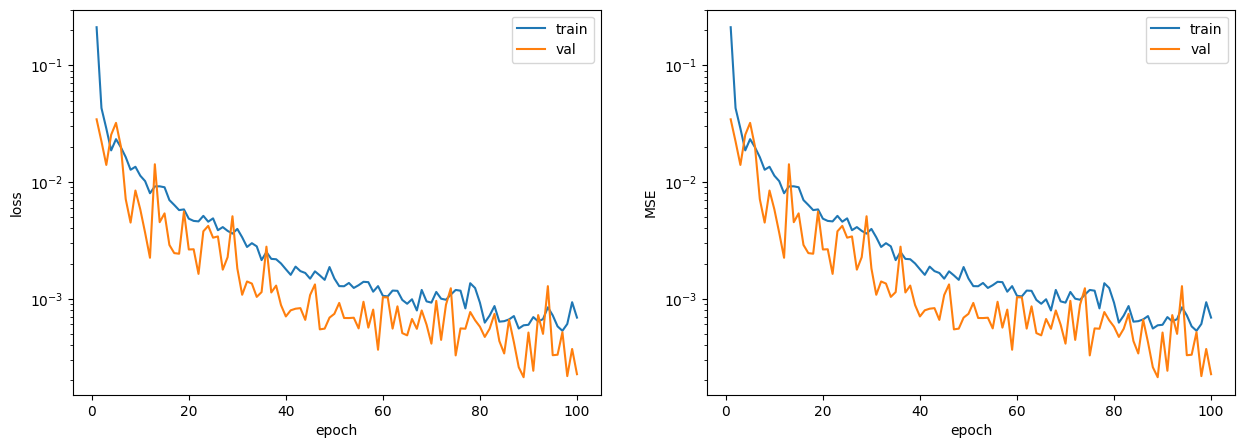

Validation MSE: 0.000

Результаты:
Train MSE: 0.0007
Val MSE: 0.0002
Val RMSE: 0.0150


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

df = pd.read_csv("train_final.csv")

def clean_numeric_strings(df):
    for col in df.columns:
        if df[col].dtype == 'object':
            try:
                cleaned = df[col].astype(str).str.replace(' ', '', regex=False)
                cleaned = cleaned.str.replace(',', '.', regex=False)
                numeric_values = pd.to_numeric(cleaned, errors='coerce')
                if numeric_values.notna().sum() > len(df) * 0.8:
                    df[col] = numeric_values
                    print(f"✓ {col}: преобразован в числовой")
                else:
                    print(f"  {col}: остается категориальным (успешно: {numeric_values.notna().sum()}/{len(df)})")
            except Exception as e:
                print(f"  {col}: остается категориальным ({str(e)[:50]})")
    return df

df = clean_numeric_strings(df)

y = df['target']
X = df.drop(['Unnamed: 0', 'id', 'address', 'address_rus'], axis=1, errors='ignore')

if 'atm_group' in X.columns:
    X = pd.get_dummies(X, columns=['atm_group'], drop_first=True)
    print(f"One-hot кодирование atm_group выполнено")

print(f"\nПропуски в y: {y.isnull().sum()}")
if y.isnull().any():
    print(f"Удаляем {y.isnull().sum()} строк с пропусками в target")
    mask = ~y.isnull()
    X = X[mask]
    y = y[mask]
    print(f"После удаления: X shape={X.shape}, y shape={y.shape}")

object_cols = X.select_dtypes(include=['object']).columns
if len(object_cols) > 0:
    print(f"\nПреобразуем object столбцы: {list(object_cols)}")
    for col in object_cols:
        X[col] = pd.to_numeric(X[col], errors='coerce')
        print(f"  {col}: преобразован")

print(f"\nПропуски в X до заполнения: {X.isnull().sum().sum()}")
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(
    imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)
print(f"Пропуски в X после заполнения: {X_imputed.isnull().sum().sum()}")

X_temp, X_test, y_temp, y_test = train_test_split(
    X_imputed, y,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print(f"\nРазмеры:")
print(f"Train: {X_train.shape}")
print(f"Val: {X_val.shape}")
print(f"Test: {X_test.shape}")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

if np.isnan(X_train_scaled).any():
    X_train_scaled = np.nan_to_num(X_train_scaled, nan=0.0)
    X_val_scaled = np.nan_to_num(X_val_scaled, nan=0.0)
    X_test_scaled = np.nan_to_num(X_test_scaled, nan=0.0)

train_dataset = TensorDataset(
    torch.FloatTensor(X_train_scaled),
    torch.FloatTensor(y_train.values)
)
val_dataset = TensorDataset(
    torch.FloatTensor(X_val_scaled),
    torch.FloatTensor(y_val.values)
)
test_dataset = TensorDataset(
    torch.FloatTensor(X_test_scaled),
    torch.FloatTensor(y_test.values)
)

train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, generator=torch.Generator().manual_seed(42))
val_loader = DataLoader(val_dataset, batch_size=256, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches: {len(val_loader)}")
print(f"Test batches: {len(test_loader)}")

model = ResidualEnsemble(
    input_size=X_train_scaled.shape[1],
    n_models=3,
    hidden_size=256,
    dropout=0.3
)


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

test_input = torch.FloatTensor(X_train_scaled[:32]).to(device)
model.eval()
with torch.no_grad():
    test_output = model(test_input)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()
metric = nn.MSELoss()

train_mse, val_mse = train_and_validate(
    model=model,
    optimizer=optimizer,
    criterion=criterion,
    metric=metric,
    train_loader=train_loader,
    val_loader=val_loader,
    num_epochs=100,
    verbose=True
)

print(f"\nРезультаты:")
print(f"Train MSE: {train_mse:.4f}")
print(f"Val MSE: {val_mse:.4f}")
print(f"Val RMSE: {np.sqrt(val_mse):.4f}")

In [5]:
model.eval()
test_preds = []
test_true = []

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_pred = model(X_batch)

        test_preds.extend(y_pred.cpu().numpy())
        test_true.extend(y_batch.numpy())

test_mse = mean_squared_error(test_true, test_preds)
test_rmse = np.sqrt(test_mse)

In [6]:
print(f'test_mse - {test_mse:.4f}')
print(f'test_rmse - {test_rmse:.4f}')

test_mse - 0.0002
test_rmse - 0.0153


In [7]:
print(f"Target statistics:")
print(f"Min: {y.min():.4f}")
print(f"Max: {y.max():.4f}")
print(f"Mean: {y.mean():.4f}")
print(f"Std: {y.std():.4f}")

relative_error = test_rmse / y.std()
print(f"Relative RMSE (RMSE/std): {relative_error:.4f}")

Target statistics:
Min: -0.1450
Max: 0.2186
Mean: 0.0007
Std: 0.0858
Relative RMSE (RMSE/std): 0.1782


In [8]:
torch.save(model.state_dict(), 'neural_network_ensemble.pth')

## Метрики на тестовой выборке

| Модель | RMSE | R² | Относительное улучшение |
|--------|------|-----|------------------------|
| **Градиентный бустинг** | 0.0143 | 0.9577 | baseline |
| **Нейросеть (Residual Ensemble)** | 0.0153 | 0.9650 | -12.6% (хуже) |

## Ключевые выводы

1. Ранее **Градиентный бустинг** показал лучший результат среди отдельных моделей
2. **Нейросеть с residual connections** (ансамбль из 3 моделей)продемонстрировала конкурентоспособное качество (R2 выше, но RMSE хуже)